<a href="https://colab.research.google.com/github/hemanthaprasad590/LDA/blob/main/LDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install nltk gensim pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 42.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from gensim.models import Phrases
from gensim.models.phrases import Phraser

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/hemanthaprasad590/LDA/d50f3ef8c58f06d5fe2c8b36912dc78be52a0218/Data.csv"

df = pd.read_csv(url, encoding='latin1')

df.head()

,Authors,Author full names,Author(s) ID,Title,Year,Source title,Volume,Issue,Art. No.,Page start,...,DOI,Link,Abstract,Author Keywords,Index Keywords,Document Type,Publication Stage,Open Access,Source,EID
0,"Thiébat, F.; Masoero, A.; Morselli, F.; Fregon...","Thiébat, Francesca (57188714085); Masoero, Ali...",57188714085; 60256964100; 60041979100; 6504273...,NATURAL FIBRES AND CIRCULARITY IN ARCHITECTURE...,2025,Agathon - International Journal of Architectur...,18,NaN,NaN,316,...,10.69143/2464-9309/18192025,https://www.scopus.com/inward/record.uri?eid=2...,Plant-based fibres demonstrate substantial pot...,life cycle assessment; life cycle costing; nat...,NaN,Article,Final,NaN,Scopus,2-s2.0-105027573187
1,"Ogwueleka, A.C.","Ogwueleka, Amaka Chinweude (55953548400)",55953548400,Supply Chain Integration in Public Sector Cons...,2025,Construction Economics and Building,25,4-Mar,NaN,272,...,10.5130/AJCEB.v25i3/4.9591,https://www.scopus.com/inward/record.uri?eid=2...,Traditional procurement practices in public se...,Adoption; Barriers; Construction Projects; Pub...,NaN,Article,Final,All Open Access; Gold Open Access,Scopus,2-s2.0-105026897798
2,"Lu, Y.; Nong, Y.; Zhu, D.; Wang, S.","Lu, Yujie (55506512700); Nong, Yuanjun (572268...",55506512700; 57226897911; 35090572500; 5944882...,Enhancing rotation you only look once version ...,2025,Engineering Applications of Artificial Intelli...,161,NaN,112176,NaN,...,10.1016/j.engappai.2025.112176,https://www.scopus.com/inward/record.uri?eid=2...,Construction material detection is integral to...,Computer vision; Construction materials detect...,Building materials; Calibration; Complex netwo...,Article,Final,All Open Access; Hybrid Gold Open Access,Scopus,2-s2.0-105015304946
3,"Zvirgzdins, J.; Weerakoon, T.G.; Geipele, I.; ...","Zvirgzdins, Janis (57215093539); Weerakoon, Th...",57215093539; 59998240200; 54406913200; 5999839...,A Comparative Analysis of Machine Learning Mod...,2025,"Engineering, Technology and Applied Science Re...",15,6,NaN,29907,...,10.48084/etasr.12724,https://www.scopus.com/inward/record.uri?eid=2...,The success of a construction project is signi...,artificial intelligence; machine learning; sup...,NaN,Article,Final,All Open Access; Gold Open Access,Scopus,2-s2.0-105027293412
4,"Firmansyah; Arifuddin, R.; Burhanuddin, S.","Firmansyah (60301726800); Arifuddin, Rosmarian...",60301726800; 57193517269; 56568157300,Analysis of Policy Barriers to the Implementat...,2025,"Engineering, Technology and Applied Science Re...",15,6,NaN,29491,...,10.48084/etasr.15146,https://www.scopus.com/inward/record.uri?eid=2...,This study assesses the application of Local C...,building; construction projects; Indonesia,NaN,Article,Final,All Open Access; Gold Open Access,Scopus,2-s2.0-105026879008


In [7]:
print(df.columns)

Index(['Authors', 'Author full names', 'Author(s) ID', 'Title', 'Year',
       'Source title', 'Volume', 'Issue', 'Art. No.', 'Page start', 'Page end',
       'Cited by', 'DOI', 'Link', 'Abstract', 'Author Keywords',
       'Index Keywords', 'Document Type', 'Publication Stage', 'Open Access',
       'Source', 'EID'],
      dtype='object')


In [8]:
df["Combined Text"] = (
    df["Title"].fillna('') + " " +
    df["Abstract"].fillna('') + " " +
    df["Author Keywords"].fillna('') + " " +
    df["Index Keywords"].fillna('')
)

In [9]:
print(df["Combined Text"].head())

0    NATURAL FIBRES AND CIRCULARITY IN ARCHITECTURE...
1    Supply Chain Integration in Public Sector Cons...
2    Enhancing rotation you only look once version ...
3    A Comparative Analysis of Machine Learning Mod...
4    Analysis of Policy Barriers to the Implementat...
Name: Combined Text, dtype: object


In [10]:
documents = df["Combined Text"].dropna().tolist()

print("Total documents:", len(documents))

Total documents: 983


In [11]:
stop_words = set(stopwords.words('english'))

domain_stopwords = [
'construction',
'material',
'materials',
'industry',
'procurement',
'supply',
'chain',
'building'
]

stop_words.update(domain_stopwords)

lemmatizer = WordNetLemmatizer()

In [12]:
def preprocess(text):

    # lowercase
    text = text.lower()

    # remove numbers and punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # tokenize
    tokens = text.split()

    # remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return tokens

In [13]:
processed_docs = [preprocess(doc) for doc in documents]

print(processed_docs[0][:20])

['natural', 'fibre', 'circularity', 'architecture', 'environmental', 'economic', 'social', 'sustainability', 'fibre', 'naturali', 'e', 'circolarit', 'architettura', 'sostenibilit', 'ambientale', 'economica', 'e', 'sociale', 'plantbased', 'fibre']


In [14]:
bigram = Phrases(processed_docs, min_count=5, threshold=10)

bigram_model = Phraser(bigram)

bigram_docs = [bigram_model[doc] for doc in processed_docs]

In [15]:
trigram = Phrases(bigram_docs, threshold=10)

trigram_model = Phraser(trigram)

trigram_docs = [trigram_model[bigram_model[doc]] for doc in processed_docs]

In [16]:
final_docs = trigram_docs

print(final_docs[0][:20])

['natural', 'fibre', 'circularity', 'architecture', 'environmental', 'economic_social', 'sustainability', 'fibre', 'naturali', 'e', 'circolarit', 'architettura', 'sostenibilit', 'ambientale', 'economica', 'e', 'sociale', 'plantbased', 'fibre', 'demonstrate']


In [17]:
!git clone https://github.com/hemanthaprasad590/LDA.git

Cloning into 'LDA'...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 7 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (7/7), 1.89 MiB | 15.21 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [18]:
%cd LDA

/content/LDA


In [19]:
df["Processed_Text"] = [' '.join(doc) for doc in final_docs]

df.to_csv("Processed_Data.csv", index=False)

In [20]:
!git config --global user.email "your_email@example.com"
!git config --global user.name "your_github_username"

In [21]:
!git add Processed_Data.csv

In [22]:
!git commit -m "Added processed dataset for LDA preprocessing step"

[main b6cafb4] Added processed dataset for LDA preprocessing step
 1 file changed, 984 insertions(+)
 create mode 100644 Processed_Data.csv


In [23]:
from gensim import corpora

dictionary = corpora.Dictionary(final_docs)

print("Total vocabulary size:", len(dictionary))

Total vocabulary size: 13905


In [24]:
dictionary.filter_extremes(
    no_below=5,     # remove words appearing in <5 documents
    no_above=0.5    # remove words appearing in >50% documents
)

In [25]:
corpus = [dictionary.doc2bow(doc) for doc in final_docs]

print("Total documents:", len(corpus))

Total documents: 983


In [26]:
from gensim.models.ldamodel import LdaModel
from gensim.models import CoherenceModel

coherence_scores = []
perplexity_scores = []
models = []

topic_range = range(3,16)

for k in topic_range:

    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=100,
        passes=20,
        alpha='auto'
    )

    models.append(lda_model)

    coherence_model = CoherenceModel(
        model=lda_model,
        texts=final_docs,
        dictionary=dictionary,
        coherence='c_v'
    )

    coherence = coherence_model.get_coherence()
    perplexity = lda_model.log_perplexity(corpus)

    coherence_scores.append(coherence)
    perplexity_scores.append(perplexity)

    print("Topics:",k,
          "Coherence:",round(coherence,4),
          "Perplexity:",round(perplexity,4))

Topics: 3 Coherence: 0.3395 Perplexity: -7.4779
Topics: 4 Coherence: 0.3809 Perplexity: -7.4643
Topics: 5 Coherence: 0.3416 Perplexity: -7.4698
Topics: 6 Coherence: 0.3667 Perplexity: -7.4765
Topics: 7 Coherence: 0.3433 Perplexity: -7.4957
Topics: 8 Coherence: 0.3331 Perplexity: -7.5157
Topics: 9 Coherence: 0.3366 Perplexity: -7.5334
Topics: 10 Coherence: 0.3395 Perplexity: -7.5476
Topics: 11 Coherence: 0.3379 Perplexity: -7.5571
Topics: 12 Coherence: 0.3204 Perplexity: -7.5719
Topics: 13 Coherence: 0.3288 Perplexity: -7.5809
Topics: 14 Coherence: 0.3258 Perplexity: -7.603
Topics: 15 Coherence: 0.3258 Perplexity: -7.6075


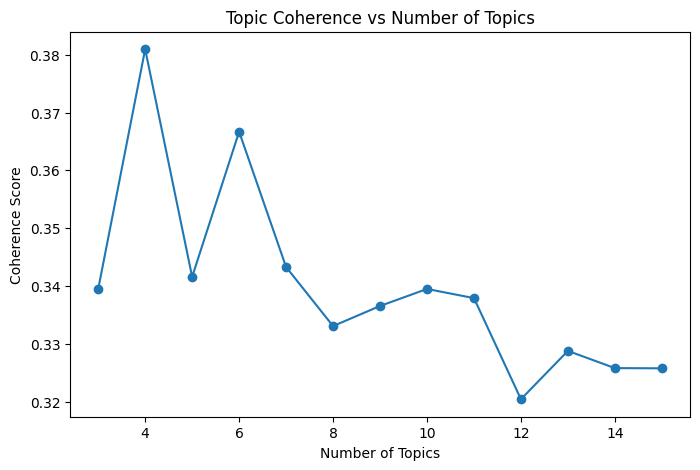

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(topic_range, coherence_scores, marker='o')
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Topic Coherence vs Number of Topics")
plt.show()

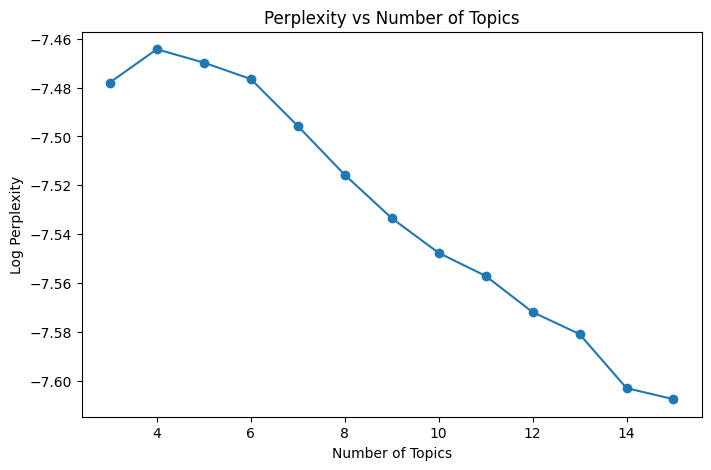

In [28]:
plt.figure(figsize=(8,5))
plt.plot(topic_range, perplexity_scores, marker='o')
plt.xlabel("Number of Topics")
plt.ylabel("Log Perplexity")
plt.title("Perplexity vs Number of Topics")
plt.show()

In [31]:
optimal_topics = 4

lda_model = models[topic_range.index(optimal_topics)]

In [32]:
for topic_id, topic in lda_model.print_topics(num_words=15):

    print("Topic", topic_id+1)
    print(topic)
    print()

Topic 1
0.034*"project" + 0.012*"risk" + 0.012*"factor" + 0.010*"management" + 0.009*"cost" + 0.006*"contractor" + 0.006*"model" + 0.006*"analysis" + 0.005*"impact" + 0.005*"performance" + 0.005*"delay" + 0.005*"research" + 0.005*"method" + 0.005*"supplier" + 0.004*"resilience"

Topic 2
0.008*"concrete" + 0.006*"energy" + 0.006*"analysis" + 0.006*"production" + 0.006*"environmental_impact" + 0.005*"building" + 0.005*"emission" + 0.005*"environmental" + 0.005*"system" + 0.005*"impact" + 0.005*"potential" + 0.005*"cement" + 0.004*"recycling" + 0.004*"product" + 0.004*"assessment"

Topic 3
0.023*"management" + 0.011*"project" + 0.010*"logistics" + 0.010*"model" + 0.009*"performance" + 0.009*"system" + 0.008*"process" + 0.006*"cost" + 0.006*"information" + 0.006*"research" + 0.005*"method" + 0.005*"quality" + 0.005*"based" + 0.005*"supplier" + 0.004*"using"

Topic 4
0.008*"research" + 0.008*"green" + 0.008*"waste" + 0.008*"management" + 0.007*"sustainability" + 0.007*"sustainable" + 0.006*

In [33]:
doc_topics = []

for doc in corpus:

    topic_distribution = lda_model.get_document_topics(doc)

    dominant_topic = max(topic_distribution, key=lambda x: x[1])[0]

    doc_topics.append(dominant_topic)

df["Dominant_Topic"] = doc_topics

In [35]:
!pip install pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 28.1 MB/s eta 0:00:00


In [36]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [39]:
lda_display = gensimvis.prepare(
    lda_model,
    corpus,
    dictionary,
    sort_topics=False
)

pyLDAvis.display(lda_display)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [40]:
pyLDAvis.save_html(lda_display, "LDA_Topic_Visualization.html")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [41]:
from google.colab import files
files.download("LDA_Topic_Visualization.html")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [42]:
!mv LDA_Topic_Visualization.html LDA/

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

mv: cannot move 'LDA_Topic_Visualization.html' to 'LDA/': Not a directory


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

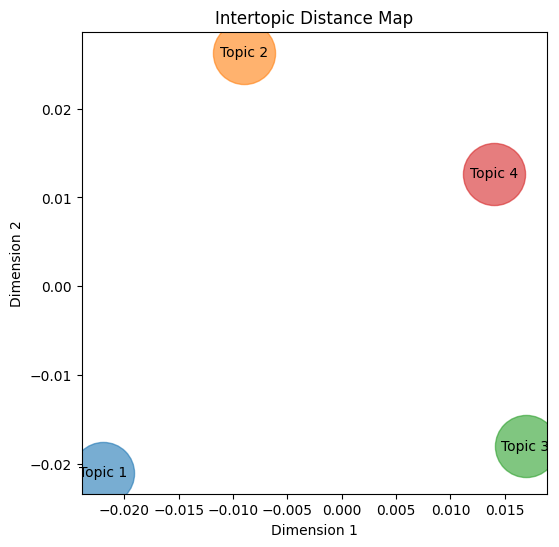

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [38]:
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
import numpy as np

topic_term = lda_model.get_topics()

mds = MDS(n_components=2, random_state=0)
coords = mds.fit_transform(topic_term)

plt.figure(figsize=(6,6))

for i, (x,y) in enumerate(coords):
    plt.scatter(x,y,s=2000,alpha=0.6)
    plt.text(x,y,f"Topic {i+1}",ha='center',va='center')

plt.title("Intertopic Distance Map")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

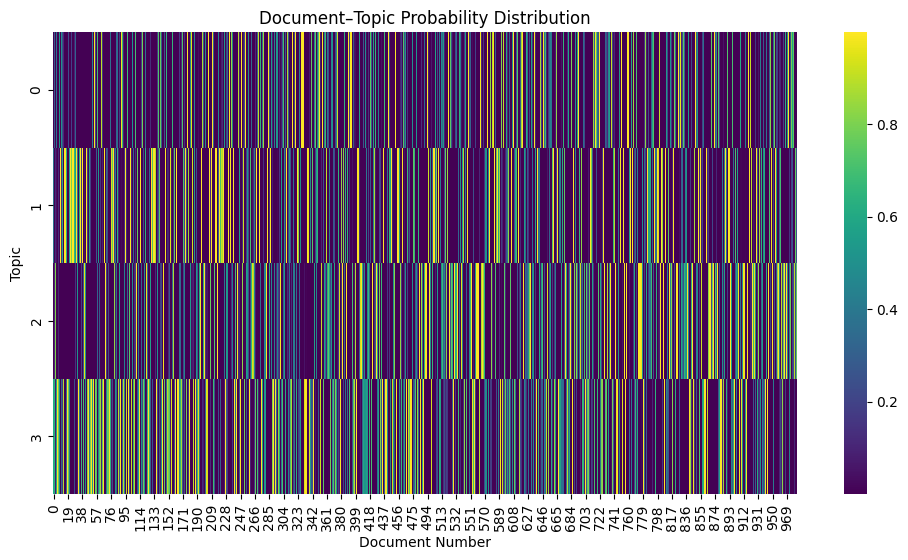

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

topic_matrix = []

for doc in corpus:
    topic_dist = lda_model.get_document_topics(doc, minimum_probability=0)
    topic_matrix.append([prob for _, prob in topic_dist])

topic_df = pd.DataFrame(topic_matrix)

plt.figure(figsize=(12,6))
sns.heatmap(topic_df.T, cmap="viridis")

plt.xlabel("Document Number")
plt.ylabel("Topic")
plt.title("Document–Topic Probability Distribution")

plt.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

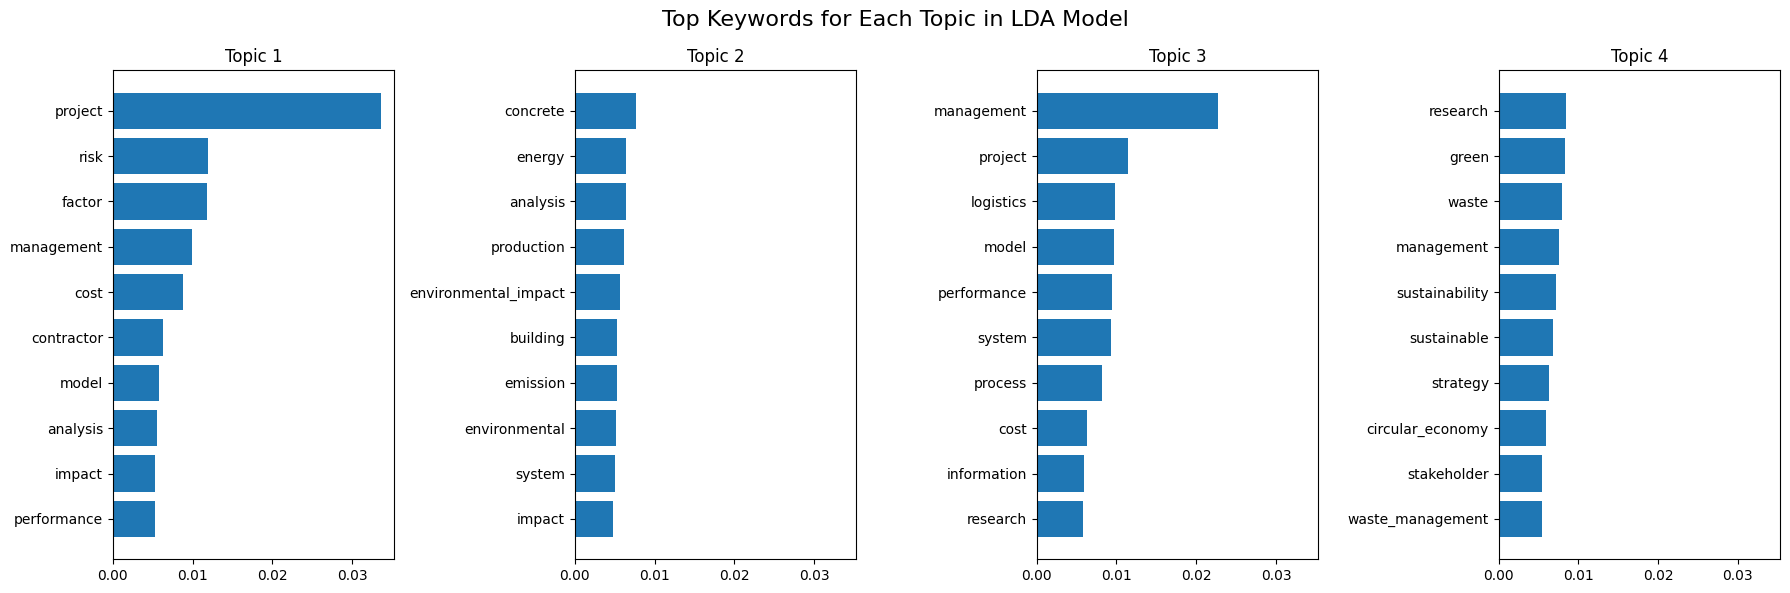

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

num_words = 10
num_topics = lda_model.num_topics

fig, axes = plt.subplots(1, num_topics, figsize=(18,6), sharex=True)

for topic_idx, ax in enumerate(axes):

    topic = lda_model.show_topic(topic_idx, num_words)

    words = [w for w, p in topic]
    probs = [p for w, p in topic]

    ax.barh(words, probs)
    ax.set_title(f"Topic {topic_idx+1}")
    ax.invert_yaxis()

plt.suptitle("Top Keywords for Each Topic in LDA Model", fontsize=16)

plt.tight_layout()

plt.show()

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

documents = [' '.join(doc) for doc in final_docs]

vectorizer = TfidfVectorizer(max_features=50)

tfidf_matrix = vectorizer.fit_transform(documents)

terms = vectorizer.get_feature_names_out()

scores = tfidf_matrix.mean(axis=0).A1

tfidf_df = pd.DataFrame({
    "term": terms,
    "score": scores
}).sort_values(by="score", ascending=False)

tfidf_df.head(20)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,term,score
31,project,0.129995
20,management,0.112325
40,study,0.080261
22,model,0.079305
44,system,0.077246
34,research,0.072401
24,performance,0.070989
1,analysis,0.070546
7,cost,0.070248
12,factor,0.066331


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

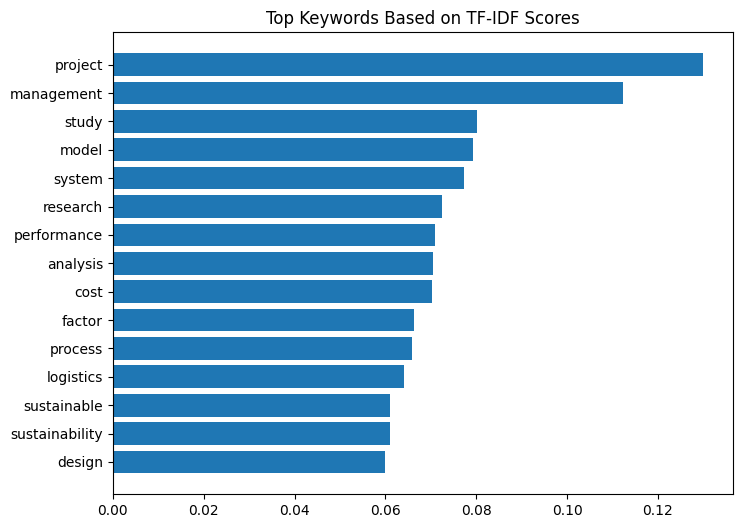

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [46]:
import matplotlib.pyplot as plt

top_terms = tfidf_df.head(15)

plt.figure(figsize=(8,6))

plt.barh(top_terms["term"], top_terms["score"])

plt.gca().invert_yaxis()

plt.title("Top Keywords Based on TF-IDF Scores")

plt.show()

In [47]:
doc_topics = []

for doc in corpus:
    topic_distribution = lda_model.get_document_topics(doc)
    dominant_topic = max(topic_distribution, key=lambda x: x[1])[0]
    doc_topics.append(dominant_topic)

df["Dominant_Topic"] = doc_topics

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [48]:
topic_year = df.groupby(["Year","Dominant_Topic"]).size().reset_index(name="Count")

topic_year.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,Year,Dominant_Topic,Count
0,1990,2,1
1,1994,2,1
2,1995,1,1
3,1995,2,1
4,1996,0,1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [49]:
topic_trend = topic_year.pivot(index="Year",
                               columns="Dominant_Topic",
                               values="Count").fillna(0)

topic_trend.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Dominant_Topic,0,1,2,3
Year,,,,
1990,0.0,0.0,1.0,0.0
1994,0.0,0.0,1.0,0.0
1995,0.0,1.0,1.0,0.0
1996,1.0,0.0,0.0,0.0
1997,1.0,0.0,1.0,0.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

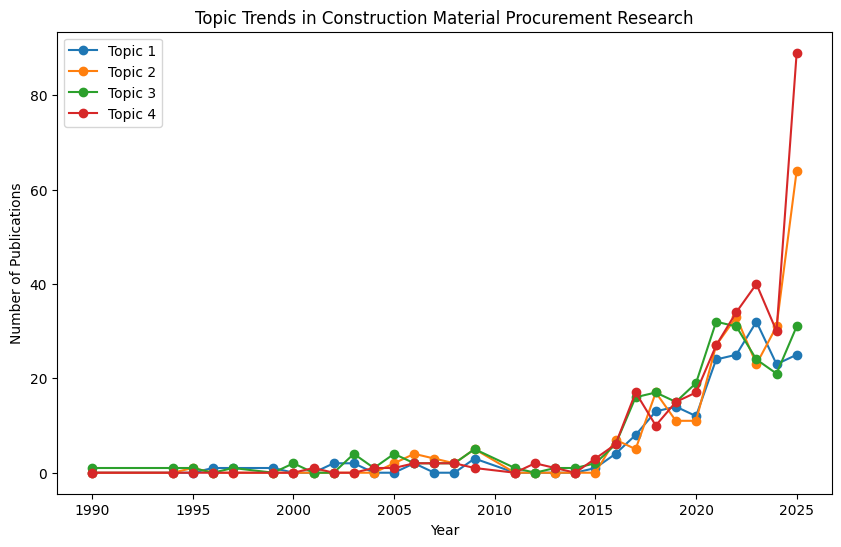

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for topic in topic_trend.columns:
    plt.plot(topic_trend.index,
             topic_trend[topic],
             marker='o',
             label=f"Topic {topic+1}")

plt.xlabel("Year")
plt.ylabel("Number of Publications")
plt.title("Topic Trends in Construction Material Procurement Research")

plt.legend()
plt.show()

In [51]:
year_counts = df["Year"].value_counts().sort_index()

year_counts.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,count
Year,
1990,1
1994,1
1995,2
1996,1
1997,2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

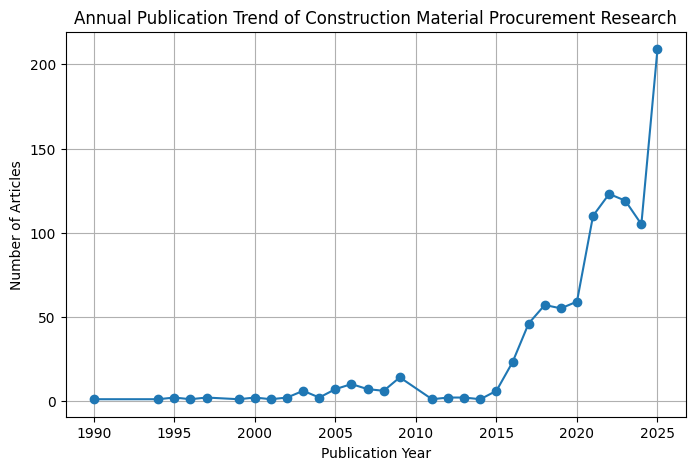

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(year_counts.index,
         year_counts.values,
         marker='o')

plt.xlabel("Publication Year")
plt.ylabel("Number of Articles")
plt.title("Annual Publication Trend of Construction Material Procurement Research")

plt.grid(True)

plt.show()